#  Deformable DETR — AU-AIR

##  Google Drive Connection

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
IMAGES_DIR = '/content/drive/MyDrive/DI725_assignment2_e274020/auair_dataset/images'
ANNOT_FILE = '/content/drive/MyDrive/DI725_assignment2_e274020/auair_dataset/annotations.json'
OUTPUT_DIR = '/content/drive/MyDrive/DI725_assignment2_e274020/output_fast'


## 2️⃣ Bağımlılıklar

In [ ]:
%%capture
!pip install transformers accelerate timm pycocotools -q

## Import Libraries

In [ ]:
import os, json, random, time, tempfile
from collections import defaultdict
from pathlib import Path

import numpy as np
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torch.cuda.amp import autocast, GradScaler   # ← Mixed Precision for faster training

from transformers import (
    AutoImageProcessor,
    AutoModelForObjectDetection,
    get_cosine_schedule_with_warmup,
)
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ══════════════════════════════════════════════════
#  HYPERPARAMETERS
# ══════════════════════════════════════════════════
CATEGORIES   = ['Human', 'Car', 'Truck', 'Van', 'Motorbike', 'Bicycle', 'Bus', 'Trailer'] # Target object classes
NUM_CLASSES  = len(CATEGORIES) # Total number of classes
SEED         = 42 # Random seed for reproducibility
VAL_RATIO    = 0.1 # Proportion of data to be used for validation

BATCH_SIZE   = 8 # Number of samples per batch
NUM_EPOCHS   = 12 # Total number of training epochs
LR_BACKBONE  = 1e-5 # Learning rate for the backbone network
LR_HEAD      = 1e-4 # Learning rate for the detection head
WEIGHT_DECAY = 1e-4 # Weight decay for regularization
WARMUP_RATIO = 0.05 # Ratio of total steps used for learning rate warmup
IMG_SHORT    = 320 # Shortest edge size for image resizing
IMG_LONG     = 480 # Longest edge size for image resizing
GRAD_CLIP    = 0.1 # Maximum gradient norm for clipping
SAVE_EVERY   = 2          # Save checkpoint every 2 epochs
USE_AMP      = True       # Enable Mixed Precision (fp16) for faster and memory-efficient training

MODEL_NAME   = 'SenseTime/deformable-detr' # Hugging Face model identifier
DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # Use GPU if available, else CPU
# ══════════════════════════════════════════════════

# Set random seeds to ensure reproducibility across different runs
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Create output directory if it doesn't exist
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Print system and configuration details
print(f'Device  : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
print(f'AMP     : {USE_AMP}')
print(f'Img size: {IMG_SHORT}x{IMG_LONG}  |  Batch: {BATCH_SIZE}  |  Epochs: {NUM_EPOCHS}')


Device  : cuda
GPU     : Tesla T4
VRAM    : 15.6 GB
AMP     : True
Img size: 320x480  |  Batch: 8  |  Epochs: 12


## Annotation → COCO Format

In [ ]:
def auair_to_coco(annot_path, images_dir, val_ratio=0.1, seed=42):
    """
    Converts AU-AIR dataset annotations to COCO format and splits into train/val.
    """
    # Load the original JSON annotations
    with open(annot_path) as f:
        raw = json.load(f)

    # Create COCO categories dictionary
    coco_cats = [
        {'id': i+1, 'name': c, 'supercategory': 'object'}
        for i, c in enumerate(raw['categories'])
    ]

    images_list, anns_list = [], []
    img_id = ann_id = 1

    # Process each image and its annotations
    for record in raw['annotations']:
        fname = record['image_name']
        # Skip if image file does not exist
        if not os.path.exists(os.path.join(images_dir, fname)):
            continue

        # Get image dimensions, defaulting width to 1920 if not explicitly provided correctly
        W = int(record.get('image_width:', record.get('image_width', 1920)))
        H = int(record['image_height'])
        images_list.append({'id': img_id, 'file_name': fname, 'width': W, 'height': H})

        # Process bounding boxes for the current image
        for b in record.get('bbox', []):
            # Ensure bounding box coordinates are within image boundaries
            x1 = max(0, b['left'])
            y1 = max(0, b['top'])
            x2 = min(W, b['left'] + b['width'])
            y2 = min(H, b['top']  + b['height'])
            bw, bh = x2 - x1, y2 - y1

            # Skip invalid bounding boxes (width or height <= 0)
            if bw <= 0 or bh <= 0:
                continue

            # Append annotation in COCO format
            anns_list.append({
                'id': ann_id, 'image_id': img_id,
                'category_id': int(b['class']) + 1, # COCO categories start at 1
                'bbox': [x1, y1, bw, bh],
                'area': bw * bh, 'iscrowd': 0
            })
            ann_id += 1
        img_id += 1

    # Set random seed for consistent splitting
    random.seed(seed)
    all_ids = [i['id'] for i in images_list]
    random.shuffle(all_ids)

    # Determine number of validation images
    val_n   = max(1, int(len(all_ids) * val_ratio))
    val_ids = set(all_ids[:val_n]) # IDs for validation set
    trn_ids = set(all_ids[val_n:]) # IDs for training set

    def split(ids):
        """
        Helper function to filter images and annotations based on a set of IDs.
        """
        return {
            'info': {'description': 'AU-AIR COCO'},
            'categories': coco_cats,
            'images':     [i for i in images_list if i['id'] in ids],
            'annotations':[a for a in anns_list   if a['image_id'] in ids],
        }

    # Create train and validation dictionaries
    tr, vl = split(trn_ids), split(val_ids)
    print(f'Train: {len(tr["images"]):,} img  {len(tr["annotations"]):,} ann')
    print(f'Val  : {len(vl["images"]):,} img  {len(vl["annotations"]):,} ann')
    return tr, vl


# Execute the conversion and splitting
train_coco, val_coco = auair_to_coco(ANNOT_FILE, IMAGES_DIR, VAL_RATIO, SEED)

# Define paths for the new COCO JSON files
COCO_TRAIN = '/content/train_coco.json'
COCO_VAL   = '/content/val_coco.json'

# Save the generated COCO dictionaries to JSON files
json.dump(train_coco, open(COCO_TRAIN, 'w'))
json.dump(val_coco,   open(COCO_VAL,   'w'))
print('✅ COCO JSON ready.')


Train: 29,541 img  118,990 ann
Val  : 3,282 img  12,987 ann
✅ COCO JSON hazır.


## Dataset

In [ ]:
class AUAIRDataset(Dataset):
    """
    Custom PyTorch Dataset for the AU-AIR Object Detection task.
    """
    def __init__(self, coco_dict, images_dir, processor, is_train=True):
        self.images_dir = images_dir
        self.processor  = processor # HuggingFace ImageProcessor
        self.is_train   = is_train

        # Map image IDs to image metadata
        self.images     = {img['id']: img for img in coco_dict['images']}
        self.img_ids    = list(self.images.keys())

        # Map image IDs to their corresponding annotations
        self.anns       = defaultdict(list)
        for ann in coco_dict['annotations']:
            self.anns[ann['image_id']].append(ann)

    def __len__(self):
        # Return the total number of images
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_id  = self.img_ids[idx]
        rec     = self.images[img_id]
        # Load the image and convert to RGB
        image   = Image.open(os.path.join(self.images_dir, rec['file_name'])).convert('RGB')
        W, H    = image.size

        # Data Augmentation: Horizontal flip with 50% probability during training
        flip = self.is_train and random.random() < 0.5
        if flip:
            image = T.functional.hflip(image)

        # Data Augmentation: Color jittering during training
        if self.is_train:
            image = T.ColorJitter(
                brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1
            )(image)

        boxes, labels = [], []
        for ann in self.anns[img_id]:
            x, y, bw, bh = ann['bbox']
            # Adjust bounding box coordinates if the image was flipped
            if flip:
                x = W - x - bw
            boxes.append([x, y, bw, bh])
            labels.append(ann['category_id'])

        # Prepare the target dictionary in the expected format for the processor
        target = {
            'image_id': img_id,
            'annotations': [
                {'bbox': b, 'category_id': l, 'area': b[2]*b[3], 'iscrowd': 0}
                for b, l in zip(boxes, labels)
            ]
        }

        # Apply the processor to encode the image and targets
        enc = self.processor(images=image, annotations=target, return_tensors='pt')

        # Squeeze out the batch dimension added by the processor
        return (
            enc['pixel_values'].squeeze(0),
            enc['pixel_mask'].squeeze(0),
            enc['labels'][0]
        )


def collate_fn(batch):
    """
    Custom collate function to batch the data correctly for the DataLoader.
    """
    return (
        torch.stack([b[0] for b in batch]), # Stack pixel_values
        torch.stack([b[1] for b in batch]), # Stack pixel_masks
        [b[2] for b in batch]               # Keep labels as a list of dictionaries
    )

print('Dataset is ready.')


Dataset hazır.


## Processor & Model & DataLoader

In [ ]:
processor = AutoImageProcessor.from_pretrained(
    MODEL_NAME,
    size={'shortest_edge': IMG_SHORT, 'longest_edge': IMG_LONG}  # Resize images to 320x480
)

# Create mappings between class IDs and labels (0 is reserved for 'N/A' or background)
id2label = {0: 'N/A'}
id2label.update({i+1: c for i, c in enumerate(CATEGORIES)})
label2id = {v: k for k, v in id2label.items()}

# Load the pre-trained Deformable DETR model with our custom labels
model = AutoModelForObjectDetection.from_pretrained(
    MODEL_NAME,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True, # Ignore size mismatches for the classification head
).to(DEVICE)

# ── DataLoaders ───────────────────────────────────────────────────
# Using persistent_workers + prefetch_factor keeps the CPU-GPU pipeline full for faster data loading
train_ds = AUAIRDataset(train_coco, IMAGES_DIR, processor, is_train=True)
val_ds   = AUAIRDataset(val_coco,   IMAGES_DIR, processor, is_train=False)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=4, pin_memory=True, # pin_memory speeds up transfer to GPU
    persistent_workers=True, prefetch_factor=2,
    collate_fn=collate_fn
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=4, pin_memory=True,
    persistent_workers=True, prefetch_factor=2,
    collate_fn=collate_fn
)

print(f'Train batches: {len(train_loader):,}  |  Val batches: {len(val_loader):,}')
print(f'Model params : {sum(p.numel() for p in model.parameters()):,}')


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/305 [00:00<?, ?B/s]

The image processor of type `DeformableDetrImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/161M [00:00<?, ?B/s]

...

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:2586: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  module._load_from_state_dict(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/batchnorm.py:133: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  super()._load_from_state_dict(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/batchnorm.py:133: UserWarning: for bn1.bias: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, whi

Loading weights:   0%|          | 0/545 [00:00<?, ?it/s]

DeformableDetrForObjectDetection LOAD REPORT from: SenseTime/deformable-detr
Key                                                                         | Status     |                                                                                      
----------------------------------------------------------------------------+------------+--------------------------------------------------------------------------------------
model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                      
model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                      
model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                      
model.backbone.conv_encoder.model.laye

Train batches: 3,693  |  Val batches: 411
Model params : 40,723,216


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


## Optimizer, Scheduler & AMP Scaler

In [ ]:
# Separate model parameters into backbone and head for differential learning rates
backbone_params, head_params = [], []
for name, param in model.named_parameters():
    if not param.requires_grad:
        continue
    # Assign parameters to the respective lists
    (backbone_params if 'backbone' in name else head_params).append(param)

# Initialize the AdamW optimizer with different learning rates for backbone and head
optimizer = torch.optim.AdamW(
    [{'params': backbone_params, 'lr': LR_BACKBONE},
     {'params': head_params,     'lr': LR_HEAD}],
    weight_decay=WEIGHT_DECAY
)

# Calculate total training steps and warmup steps
total_steps  = NUM_EPOCHS * len(train_loader)
warmup_steps = int(total_steps * WARMUP_RATIO)

# Initialize the learning rate scheduler (Cosine annealing with linear warmup)
scheduler    = get_cosine_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

# Initialize the GradScaler for Automatic Mixed Precision (AMP)
scaler = GradScaler(enabled=USE_AMP)

print(f'Total step : {total_steps:,}  |  Warmup: {warmup_steps:,}')


Total step : 44,316  |  Warmup: 2,215


/tmp/ipykernel_1108/2974376787.py:21: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=USE_AMP)


## Checkpoint Resume

In [ ]:
RESUME_FILE = os.path.join(OUTPUT_DIR, 'last_checkpoint.pt')
history     = []
start_epoch = 1
best_loss   = float('inf')

if os.path.exists(RESUME_FILE):
    print("A checkpoint has been found; continuing from where we left off...")
    # Load the checkpoint file containing optimizer, scheduler, and other training states
    ckpt = torch.load(RESUME_FILE, map_location=DEVICE)

    # Load the model weights and processor from the saved directory
    resume_model_dir = os.path.join(OUTPUT_DIR, 'last_model')
    if os.path.exists(resume_model_dir):
        model = AutoModelForObjectDetection.from_pretrained(
            resume_model_dir,
            id2label=id2label, label2id=label2id,
            ignore_mismatched_sizes=True
        ).to(DEVICE)

    # Restore the optimizer, scheduler, and scaler states from the checkpoint
    optimizer.load_state_dict(ckpt['optimizer'])
    scheduler.load_state_dict(ckpt['scheduler'])
    scaler.load_state_dict(ckpt['scaler'])

    # Resume training from the next epoch
    start_epoch = ckpt['epoch'] + 1
    best_loss   = ckpt['best_loss']
    history     = ckpt['history']
    print(f'Continues form Epoch {ckpt["epoch"]}". Best loss: {best_loss:.4f}')
else:
    print('The training starts from scratch.')


def save_checkpoint(epoch, best_loss, history):
    """Save the state to Drive at the end of each epoch."""

    # Save the current model weights and processor
    model.save_pretrained(os.path.join(OUTPUT_DIR, 'last_model'))
    processor.save_pretrained(os.path.join(OUTPUT_DIR, 'last_model'))

    # Save the training states (optimizer, scheduler, scaler, etc.) to a checkpoint file
    torch.save({
        'epoch'    : epoch,
        'optimizer': optimizer.state_dict(),
        'scheduler': scheduler.state_dict(),
        'scaler'   : scaler.state_dict(),
        'best_loss': best_loss,
        'history'  : history,
    }, RESUME_FILE)

print('Resume system is ready')

The training starts from scratch.
Resume system is ready


## Training

In [ ]:
def train_one_epoch(model, loader, optimizer, scheduler, scaler, device, epoch):
    model.train()
    total_loss = 0.0
    t0 = time.time()

    for step, (pixel_values, pixel_mask, labels) in enumerate(loader):
        # Move tensors to the designated device (GPU or CPU)
        pixel_values = pixel_values.to(device, non_blocking=True)
        pixel_mask   = pixel_mask.to(device,   non_blocking=True)
        labels       = [{k: v.to(device, non_blocking=True)
                         for k, v in lbl.items()} for lbl in labels]

        # Reset gradients. set_to_none=True is faster than zeroing
        optimizer.zero_grad(set_to_none=True)

        # Forward pass with Automatic Mixed Precision (AMP) for speed
        with autocast(enabled=USE_AMP):
            outputs = model(
                pixel_values=pixel_values,
                pixel_mask=pixel_mask,
                labels=labels
            )
            loss = outputs.loss

        # Backward pass using the scaler
        scaler.scale(loss).backward()
        # Unscale gradients before clipping to prevent gradient explosion
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)

        # Update optimizer and scaler
        scaler.step(optimizer)
        scaler.update()
        # Update learning rate scheduler
        scheduler.step()

        total_loss += loss.item()

        # Print progress every 50 steps
        if (step + 1) % 50 == 0:
            elapsed = time.time() - t0
            avg     = total_loss / (step + 1)
            eta_min = (elapsed / (step+1)) * (len(loader) - step - 1) / 60
            print(f'  Epoch {epoch} | {step+1}/{len(loader)} '
                  f'| Loss: {avg:.4f} | ETA: {eta_min:.1f} mins')

    return total_loss / len(loader)


@torch.no_grad()
def validate(model, loader, device):
    model.eval()
    total = 0.0
    for pixel_values, pixel_mask, labels in loader:
        # Move tensors to the designated device
        pixel_values = pixel_values.to(device, non_blocking=True)
        pixel_mask   = pixel_mask.to(device,   non_blocking=True)
        labels       = [{k: v.to(device) for k, v in lbl.items()} for lbl in labels]

        # Forward pass with AMP
        with autocast(enabled=USE_AMP):
            out = model(pixel_values=pixel_values,
                        pixel_mask=pixel_mask, labels=labels)
        total += out.loss.item()
    return total / len(loader)


# Main training loop
for epoch in range(start_epoch, NUM_EPOCHS + 1):
    print(f'\n{'═'*60}')
    print(f'  EPOCH {epoch}/{NUM_EPOCHS}')
    print(f'{'═'*60}')

    t_epoch = time.time()

    # Train for one epoch
    train_loss = train_one_epoch(
        model, train_loader, optimizer, scheduler, scaler, DEVICE, epoch
    )

    # Validate the model
    val_loss = validate(model, val_loader, DEVICE)

    epoch_min = (time.time() - t_epoch) / 60
    print(f'\n  ✔ Train: {train_loss:.4f}  Val: {val_loss:.4f}  '
          f'({epoch_min:.1f} mins)')

    # Record history
    history.append({'epoch': epoch,
                    'train_loss': train_loss,
                    'val_loss':   val_loss})

    # Save the best model based on validation loss
    if val_loss < best_loss:
        best_loss = val_loss
        best_dir  = os.path.join(OUTPUT_DIR, 'best_model')
        model.save_pretrained(best_dir)
        processor.save_pretrained(best_dir)
        print(f' The Best model is saved! (val_loss={best_loss:.4f})')

    # Save checkpoint periodically and at the end of each epoch
    save_checkpoint(epoch, best_loss, history)
    if epoch % SAVE_EVERY == 0:
        ckpt_dir = os.path.join(OUTPUT_DIR, f'epoch_{epoch:02d}')
        model.save_pretrained(ckpt_dir)
        processor.save_pretrained(ckpt_dir)
        print(f'Epoch checkpoint → {ckpt_dir}')

print('\n End of the training!')



════════════════════════════════════════════════════════════
  EPOCH 1/12
════════════════════════════════════════════════════════════


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/tmp/ipykernel_1108/3479966402.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):
/tmp/ipykernel_1108/3479966402.py:28: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate

  Epoch 1 | 50/3693 | Loss: 116.1039 | ETA: 124.7 dk
  Epoch 1 | 100/3693 | Loss: 108.3346 | ETA: 122.5 dk
  Epoch 1 | 150/3693 | Loss: 93.0267 | ETA: 118.1 dk
  Epoch 1 | 200/3693 | Loss: 77.4891 | ETA: 114.4 dk
  Epoch 1 | 250/3693 | Loss: 64.5522 | ETA: 115.0 dk
  Epoch 1 | 300/3693 | Loss: 55.0881 | ETA: 112.8 dk
  Epoch 1 | 350/3693 | Loss: 47.8685 | ETA: 110.3 dk
  Epoch 1 | 400/3693 | Loss: 42.3210 | ETA: 107.8 dk
  Epoch 1 | 450/3693 | Loss: 37.9772 | ETA: 105.3 dk
  Epoch 1 | 500/3693 | Loss: 34.4576 | ETA: 103.3 dk
  Epoch 1 | 550/3693 | Loss: 31.5628 | ETA: 101.1 dk
  Epoch 1 | 600/3693 | Loss: 29.1353 | ETA: 99.7 dk
  Epoch 1 | 650/3693 | Loss: 27.0732 | ETA: 97.6 dk
  Epoch 1 | 700/3693 | Loss: 25.2946 | ETA: 95.7 dk
  Epoch 1 | 750/3693 | Loss: 23.7504 | ETA: 93.9 dk
  Epoch 1 | 800/3693 | Loss: 22.3938 | ETA: 92.2 dk
  Epoch 1 | 850/3693 | Loss: 21.1922 | ETA: 90.4 dk
  Epoch 1 | 900/3693 | Loss: 20.1218 | ETA: 88.6 dk
  Epoch 1 | 950/3693 | Loss: 19.1621 | ETA: 87.0 dk


/tmp/ipykernel_1108/3479966402.py:50: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):



  ✔ Train: 6.1347  Val: 1.5723  (119.2 dk)


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

 The Best model is saved! (val_loss=1.1275)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch checkpoint → /content/drive/MyDrive/DI725_assignment2_e274020/output_fast/epoch_12

 End of the training!


## Loss Curve

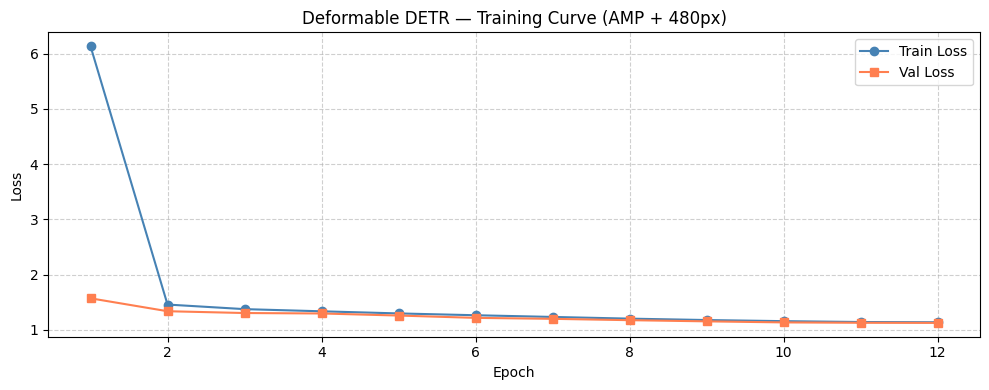

In [ ]:
# Extract epoch numbers, training losses, and validation losses from the history list
epochs_v = [h['epoch']      for h in history]
train_v  = [h['train_loss'] for h in history]
val_v    = [h['val_loss']   for h in history]

# Create a figure and axis for the loss curve plot
fig, ax = plt.subplots(figsize=(10, 4))

# Plot training and validation losses
ax.plot(epochs_v, train_v, 'o-', label='Train Loss', color='steelblue')
ax.plot(epochs_v, val_v,   's-', label='Val Loss',   color='coral')

# Set axis labels and title
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Deformable DETR — Training Curve (AMP + 480px)')

# Add legend and grid for better readability
ax.legend(); ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Save the plot to the output directory and display it
plt.savefig(os.path.join(OUTPUT_DIR, 'loss_curve.png'), dpi=150)
plt.show()


##Category-wise Average Precision

In [ ]:
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

# Load the best performing model from the output directory
best_dir   = os.path.join(OUTPUT_DIR, 'best_model')
model_eval = AutoModelForObjectDetection.from_pretrained(best_dir).to(DEVICE)
model_eval.eval() # Set model to evaluation mode
print('Best model loaded successfully.')

CONF_THRESH  = 0.3 # Confidence threshold for object detection
coco_results = [] # List to store detection results in COCO format

# Disable gradient calculation for evaluation
with torch.no_grad():
    for pixel_values, pixel_mask, labels in val_loader:
        # Move inputs to the designated device (GPU/CPU)
        pixel_values = pixel_values.to(DEVICE)
        pixel_mask   = pixel_mask.to(DEVICE)

        # Perform forward pass with Automatic Mixed Precision (AMP)
        with autocast(enabled=USE_AMP):
            outputs = model_eval(pixel_values=pixel_values, pixel_mask=pixel_mask)

        # Extract target original sizes to scale bounding boxes correctly
        target_sizes = torch.stack([
            torch.tensor([lbl['orig_size'][0].item(),
                          lbl['orig_size'][1].item()]) for lbl in labels
        ])

        # Post-process outputs to get final bounding boxes, scores, and labels
        results = processor.post_process_object_detection(
            outputs, threshold=CONF_THRESH, target_sizes=target_sizes
        )

        # Iterate over each image's results and format them for COCO evaluation
        for lbl, res in zip(labels, results):
            img_id = lbl['image_id'].item()
            for score, cat_id, box in zip(res['scores'], res['labels'], res['boxes']):
                x1, y1, x2, y2 = box.tolist()
                coco_results.append({
                    'image_id'   : img_id,
                    'category_id': int(cat_id),
                    'bbox'       : [x1, y1, x2-x1, y2-y1], # COCO expects [x, y, width, height]
                    'score'      : float(score),
                })

print(f'Total predictions: {len(coco_results):,}')

Loading weights:   0%|          | 0/585 [00:00<?, ?it/s]

✅ Best model yüklendi.


/tmp/ipykernel_1108/1940304620.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


Toplam tahmin: 7,573


In [ ]:
if len(coco_results) == 0:
    print('No guesses. Lower the CONF_THRESH value (e.g., 0.1).')
else:
    # Load ground truth annotations for validation set
    coco_gt = COCO(COCO_VAL)

    # Save detection results to a temporary JSON file
    with tempfile.NamedTemporaryFile(mode='w', suffix='.json', delete=False) as f:
        json.dump(coco_results, f)
        tmp = f.name

    # Load detection results and initialize COCOeval for bounding box evaluation
    coco_dt   = coco_gt.loadRes(tmp)
    coco_eval = COCOeval(coco_gt, coco_dt, iouType='bbox')

    # Run the evaluation and accumulation steps
    coco_eval.evaluate()
    coco_eval.accumulate()

    print('\n' + '═'*58)
    print('  COCO General Metrics')
    print('═'*58)
    # Print standard COCO metrics summary
    coco_eval.summarize()

    # Extract precision matrix and category information
    precision = coco_eval.eval['precision']
    cat_ids   = coco_gt.getCatIds()
    cat_names = [coco_gt.loadCats([c])[0]['name'] for c in cat_ids]

    # Helper function to compute mean of valid precision values
    def mean_valid(arr):
        v = arr[arr > -1]
        return float(v.mean()) if len(v) else 0.0

    # Calculate category-wise Average Precision (AP) for different IoU thresholds
    rows = []
    for k, (cid, cname) in enumerate(zip(cat_ids, cat_names)):
        rows.append({
            'Class'     : cname,
            'AP@.50:.95': mean_valid(precision[:, :, k, 0, 2]),
            'AP@.50'    : mean_valid(precision[0, :, k, 0, 2]),
            'AP@.75'    : mean_valid(precision[5, :, k, 0, 2]),
        })

    print('\n' + '═'*58)
    print('  Category-wise Average Precision')
    print('═'*58)
    print(f'{"Class":<12} {"AP@.50:.95":>12} {"AP@.50":>8} {"AP@.75":>8}')
    print('─'*58)
    for r in rows:
        print(f'{r["Class":<12} {r["AP@.50:.95"]:>12.4f} '
              f'{r["AP@.50"]:>8.4f} {r["AP@.75"]:>8.4f}')
    print('─'*58)

    # Calculate and print Mean Average Precision (mAP) across all categories
    mean_ap = sum(r['AP@.50:.95'] for r in rows) / len(rows)
    print(f'{"mAP":<12} {mean_ap:>12.4f}')
    print('═'*58)

    # Setup bar chart for visual representation of Category-wise AP
    x   = np.arange(len(rows))
    w   = 0.3
    fig, ax = plt.subplots(figsize=(13, 5))

    # Plot bars for different IoU thresholds
    b1 = ax.bar(x - w, [r['AP@.50:.95'] for r in rows], w,
                label='AP@.50:.95', color='steelblue')
    b2 = ax.bar(x,     [r['AP@.50']     for r in rows], w,
                label='AP@.50',     color='coral')
    b3 = ax.bar(x + w, [r['AP@.75']     for r in rows], w,
                label='AP@.75',     color='mediumseagreen')

    # Draw horizontal line for mAP
    ax.axhline(mean_ap, color='navy', linestyle='--', linewidth=1.2,
               label=f'mAP={mean_ap:.3f}')

    # Chart formatting
    ax.set_xticks(x)
    ax.set_xticklabels([r['Class'] for r in rows], rotation=20, ha='right')
    ax.set_ylabel('Average Precision')
    ax.set_title('Deformable DETR — Category-wise AP (AU-AIR)')
    ax.set_ylim(0, 1.05)
    ax.legend(loc='upper right')
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)

    # Add value annotations on top of bars
    for bars in [b1, b2, b3]:
        for bar in bars:
            h = bar.get_height()
            if h > 0.01:
                ax.annotate(f'{h:.2f}',
                    xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', va='bottom', fontsize=7.5)

    plt.tight_layout()
    ap_path = os.path.join(OUTPUT_DIR, 'category_ap.png')
    plt.savefig(ap_path, dpi=150)
    plt.show()
    print(f'\nGraph saved → {ap_path}')


## Sample Prediction

/tmp/ipykernel_1108/3420445489.py:7: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


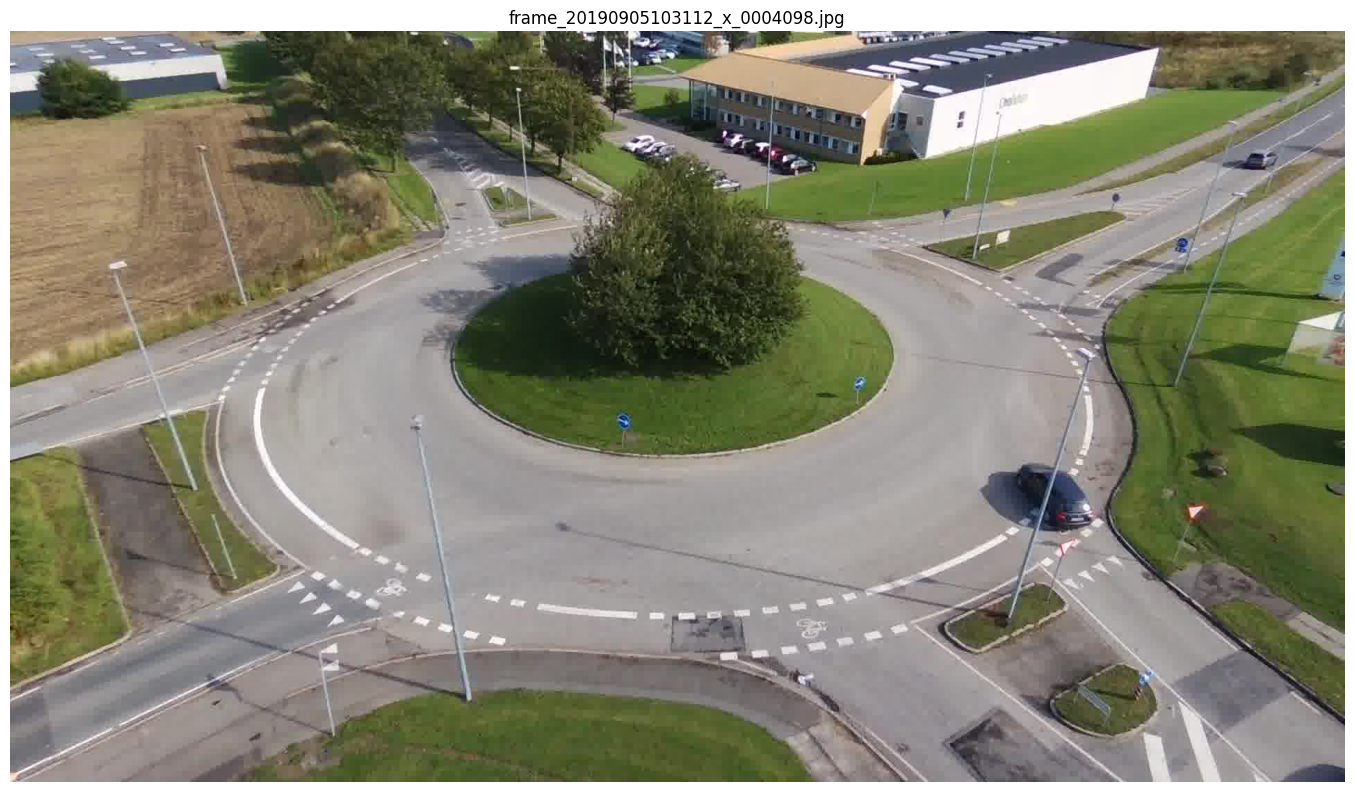

In [ ]:
# Select a random image from the validation set for visualization
sample   = random.choice(val_coco['images'])
img_path = os.path.join(IMAGES_DIR, sample['file_name'])
# Load the image and ensure it's in RGB format
image    = Image.open(img_path).convert('RGB')

# Prepare the image using the processor and move it to the device (GPU/CPU)
inputs = processor(images=image, return_tensors='pt').to(DEVICE)

# Perform inference without tracking gradients for speed and memory efficiency
with torch.no_grad():
    # Use Automatic Mixed Precision (AMP) if enabled
    with autocast(enabled=USE_AMP):
        outs = model_eval(**inputs)

# Define the target size to scale the bounding boxes correctly to the original image
target_sizes = torch.tensor([[image.height, image.width]])

# Post-process the model outputs to get bounding boxes, scores, and labels
# Only keep predictions with a confidence score above 0.35
preds = processor.post_process_object_detection(
    outs, threshold=0.35, target_sizes=target_sizes
)[0]

# Generate a set of colors for different object classes using a matplotlib colormap
COLORS = plt.cm.Set1(np.linspace(0, 1, NUM_CLASSES + 1))

# Create a figure and axis for plotting
fig, ax = plt.subplots(1, figsize=(14, 8))
# Display the original image
ax.imshow(image)

# Iterate over the predictions and draw bounding boxes and labels
for score, label, box in zip(preds['scores'], preds['labels'], preds['boxes']):
    x1, y1, x2, y2 = box.tolist()
    cat_id = int(label)
    color  = COLORS[cat_id % len(COLORS)]

    # Draw the bounding box rectangle
    ax.add_patch(patches.Rectangle(
        (x1, y1), x2-x1, y2-y1,
        linewidth=2, edgecolor=color, facecolor='none'
    ))

    # Add text label with class name and confidence score
    ax.text(x1, y1-4, f'{id2label.get(cat_id, str(cat_id))} {score:.2f}',
            color='white', fontsize=9,
            bbox=dict(facecolor=color, alpha=0.7, pad=1))

# Turn off axis ticks for a cleaner look
ax.axis('off')
# Set the image file name as the title
ax.set_title(sample['file_name'])
plt.tight_layout()

# Save the visual prediction to the output directory
plt.savefig(os.path.join(OUTPUT_DIR, 'sample_prediction.png'), dpi=150)
# Show the final plot
plt.show()
